In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as sps, stats

from src.config import PROCESSED, FIGURES, RANDOM_STATE, SAMPLING_RATE_HZ
from src.data import feature_cols

dev = pd.read_csv(PROCESSED / "dev_2v3.csv")
cols = feature_cols(dev)

dev = dev.sort_values(["segment", "chunk"])          # chunk number = time order
segs = dev.groupby("segment")
labels = segs["y"].first()
signals = np.stack([g[cols].to_numpy(dtype=float).ravel() for _, g in segs])   # one row per segment

print(signals.shape, labels.value_counts().to_dict())

(160, 4094) {3: 80, 2: 80}


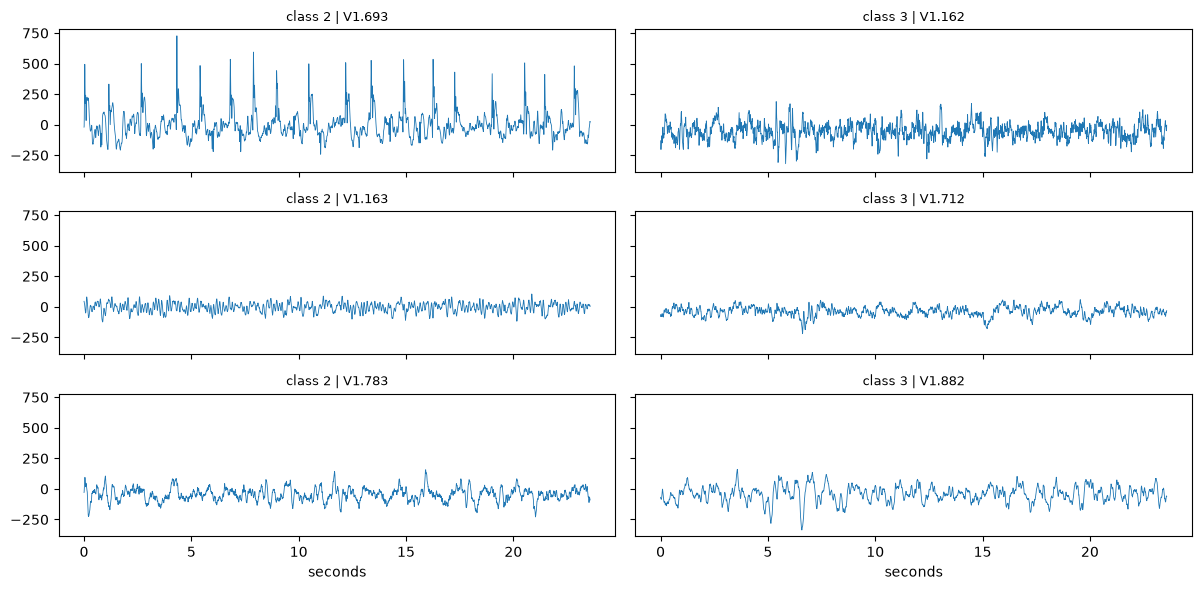

In [2]:
rng = np.random.default_rng(RANDOM_STATE)
t = np.arange(signals.shape[1]) / SAMPLING_RATE_HZ
fig, axes = plt.subplots(3, 2, figsize=(12, 6), sharex=True, sharey=True)
for j, c in enumerate([2, 3]):
    idx = rng.choice(np.where(labels.values == c)[0], 3, replace=False)
    for i, k in enumerate(idx):
        axes[i, j].plot(t, signals[k], lw=0.6)
        axes[i, j].set_title(f"class {c} | {labels.index[k]}", fontsize=9)
axes[-1, 0].set_xlabel("seconds")
axes[-1, 1].set_xlabel("seconds")
plt.tight_layout()
plt.savefig(FIGURES / "eda_01_segments.png", dpi=150)
plt.show()

In [3]:
def auc(a, b):
    """Chance that a random class-2 value is bigger than a random class-3 value. 0.5 = no difference."""
    return stats.mannwhitneyu(a, b).statistic / (len(a) * len(b))

z = (signals - signals.mean(axis=1, keepdims=True)) / signals.std(axis=1, keepdims=True)
feat = pd.DataFrame({
    "std": signals.std(axis=1),                                   # overall size
    "kurtosis": stats.kurtosis(signals, axis=1),                  # spikiness
    "line_length": np.abs(np.diff(signals, axis=1)).mean(axis=1), # average step between samples
    "max_abs_z": np.abs(z).max(axis=1),                           # biggest single spike, in std units
}, index=labels.index)
feat["y"] = labels.values

rows = []
for c in ["std", "kurtosis", "line_length", "max_abs_z"]:
    a, b = feat.loc[feat["y"] == 2, c], feat.loc[feat["y"] == 3, c]
    rows.append({"feature": c, "median_c2": a.median(), "median_c3": b.median(), "AUC": auc(a, b)})
print(pd.DataFrame(rows).round(2).to_string(index=False))

    feature  median_c2  median_c3  AUC
        std      52.13      49.11 0.55
   kurtosis       0.28       0.53 0.39
line_length       8.22       6.85 0.57
  max_abs_z       3.85       4.12 0.42


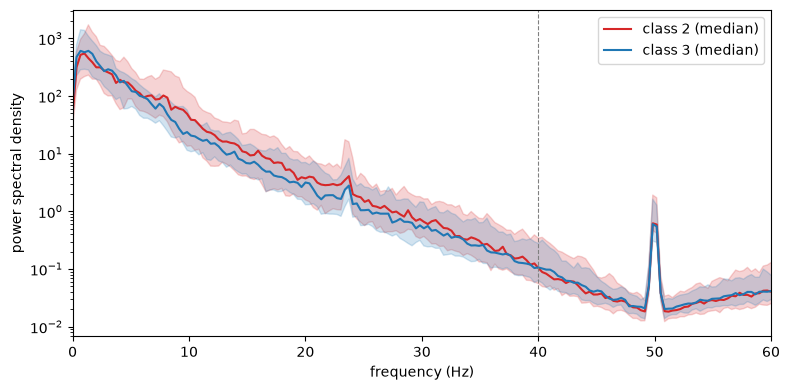

share of power above 40 Hz (median over segments): 0.0017


In [4]:
f, P = sps.welch(signals, fs=SAMPLING_RATE_HZ, nperseg=512, axis=1)   # power at each frequency, per segment
fig, ax = plt.subplots(figsize=(8, 4))
for c, col in [(2, "tab:red"), (3, "tab:blue")]:
    Pc = P[labels.values == c]
    ax.plot(f, np.median(Pc, axis=0), color=col, label=f"class {c} (median)")
    ax.fill_between(f, np.percentile(Pc, 25, axis=0), np.percentile(Pc, 75, axis=0), color=col, alpha=0.2)
ax.axvline(40, color="grey", ls="--", lw=0.8)
ax.set_xlim(0, 60)
ax.set_yscale("log")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("power spectral density")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "eda_03_spectrum.png", dpi=150)
plt.show()
print("share of power above 40 Hz (median over segments):",
      round(float(np.median(P[:, f > 40].sum(axis=1) / P.sum(axis=1))), 4))

In [5]:
bands = {"delta 0.5-4": (0.5, 4), "theta 4-8": (4, 8), "alpha 8-13": (8, 13),
         "beta 13-30": (13, 30), "gamma 30-40": (30, 40)}
total = P[:, (f >= 0.5) & (f < 40)].sum(axis=1)            # total power from 0.5 to 40 Hz, per segment
rows = []
for name, (lo, hi) in bands.items():
    rel = P[:, (f >= lo) & (f < hi)].sum(axis=1) / total   # this band's share of the total
    a, b = rel[labels.values == 2], rel[labels.values == 3]
    rows.append({"band": name, "median_c2": np.median(a), "median_c3": np.median(b), "AUC": auc(a, b)})
print(pd.DataFrame(rows).round(3).to_string(index=False))

       band  median_c2  median_c3   AUC
delta 0.5-4      0.596      0.689 0.349
  theta 4-8      0.224      0.192 0.583
 alpha 8-13      0.088      0.064 0.671
 beta 13-30      0.036      0.032 0.553
gamma 30-40      0.002      0.002 0.440


# 02 EDA: findings

Segment-level comparison of class 2 vs class 3, on the development data only (80 segments per class).

- Whole-segment traces look alike across classes. Segments within a class differ as much as segments across classes.
- Size, spikiness, jaggedness and biggest spike do not separate the classes (AUC 0.43 to 0.53).
- Average spectra overlap almost completely. Only 0.16% of power sits above 40 Hz, so frequency features should stay at or below 40 Hz. A narrow spike at 50 Hz appears in both classes.
- Band shares: class 2 has slightly less delta (0.61 vs 0.69) and slightly more theta, alpha and beta. Largest gaps: alpha AUC 0.64, delta AUC 0.38. These are weak, and the shares add up to 1, so they are not independent.
- Conclusion: no strong separator found. Expect a hard problem and modest scores. **Relative band power is the most promising lead, to be tested inside cross-validation.**